# EDA 04: Somatic Mutations and Alteration Definitions

## Purpose

DNA is the instruction manual of a cell. A mutation is a change in one or more DNA letters. A somatic mutation is a change found in the cancer model rather than a change we assume was inherited by the donor. Some mutations do little, while others damage a protein, activate an oncogene, or disable a tumour-suppressor gene.

This notebook studies the mutation summaries created from each model's selected default DNA profile. Its most important job is to define, visibly and cautiously, what we mean when we later say "gene A is altered" before asking whether those models depend on gene B.

## Questions

1. Does every row represent one model-gene summary from a valid, assayed model?
2. How many mutations are recorded per model, and does mutation burden differ by lineage?
3. Which genes recur across models, and what types of events are recorded?
4. How do likely loss-of-function, hotspot, oncogene, and tumour-suppressor flags differ?
5. How sensitive is the altered-model group to the biological definition we choose?

**Important:** no mutation row can mean "no recorded mutation" only for a model with a mutation assay. For an unassayed model, the answer is unknown.

## Considerations carried forward

- Join to models only with `model_id`; keep default DNA profile selection as provenance.
- Count one model once in a denominator, even if it has several variants in the same gene.
- Use `has_mutation_assay=1` to define where absence of a recorded mutation can be interpreted.
- Keep likely loss-of-function, hotspot, oncogene, and tumour-suppressor evidence separate before testing combined definitions.
- Treat high mutation burden or allele fraction as review/context information, not automatic proof of a driver mutation.
- Stratify by lineage and report exact assayed-model counts.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid', context='notebook')

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'depmap_24Q4' / 'architecture' / 'model_master.csv').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the az-team25 repository.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA = PROJECT_ROOT / 'data' / 'depmap_24Q4'

PATHS = {
    'master': DATA / 'architecture' / 'model_master.csv',
    'mutations': DATA / 'derived' / 'mutations_default_dna_gene_summary.csv',
    'gene_master': DATA / 'architecture' / 'gene_master.csv',
}
master = pd.read_csv(PATHS['master'], low_memory=False)
mutations = pd.read_csv(PATHS['mutations'], low_memory=False)
gene_master = pd.read_csv(PATHS['gene_master'], low_memory=False)

print(f'Model master: {len(master):,} models')
print(f'Mutation summary: {len(mutations):,} model-gene rows')
display(mutations.head())

Model master: 2,105 models
Mutation summary: 646,941 model-gene rows


,model_id,gene_id,hugo_symbol,n_variants,max_allele_fraction,has_likely_lof,has_hotspot,has_oncogene_high_impact,has_tumor_suppressor_high_impact,highest_vep_impact
0,ACH-000001,ENSG00000006715,VPS41,1,0.375,0,0,0,0,MODERATE
1,ACH-000001,ENSG00000029993,HMGB3,1,0.315,0,0,0,0,MODERATE
2,ACH-000001,ENSG00000054967,RELT,1,0.276,0,0,0,0,MODERATE
3,ACH-000001,ENSG00000075142,SRI,1,0.394,1,0,0,0,HIGH
4,ACH-000001,ENSG00000079102,RUNX1T1,1,0.829,0,0,0,0,MODERATE


## Column dictionary

| Column | Plain-language biological meaning | Use in this project |
| --- | --- | --- |
| `model_id` | DepMap cell-line identifier. | Only automatic model-level join key. |
| `gene_id` | Stable Ensembl identifier for the altered gene. | Stable gene join key; avoids ambiguous names. |
| `hugo_symbol` | Familiar gene name, such as `TP53`. | User-facing label and reviewed gene lookup. |
| `n_variants` | Number of distinct recorded variants in this gene for this model. | Mutation-count context; the model still counts once. |
| `max_allele_fraction` | Largest fraction of sequencing reads carrying one of the gene's variants. | Evidence strength/clonality context, not proof of a driver. |
| `has_likely_lof` | At least one variant is predicted to cause likely loss of function. | Candidate definition for a damaged or disabled gene. |
| `has_hotspot` | At least one variant occurs at a repeatedly observed cancer hotspot. | Driver-like evidence, often relevant to oncogenes. |
| `has_oncogene_high_impact` | At least one high-impact event is annotated for an oncogene. | Visible oncogene-activation/damage evidence. |
| `has_tumor_suppressor_high_impact` | At least one high-impact event is annotated for a tumour suppressor. | Visible evidence that a protective gene may be disrupted. |
| `highest_vep_impact` | Highest VEP consequence class among the gene's variants: HIGH, MODERATE, LOW, or MODIFIER. | Broad severity context; prediction rather than experimental proof. |

`VEP` is software that predicts how a DNA change may affect a gene or protein. `HIGH` means the change is predicted to have a severe consequence, but it is still a computational annotation.

## 1. Grain, joins, and assay denominator

The table has one row for a model-gene combination only when at least one mutation was recorded in that gene. We therefore build the full denominator from `model_master`, not from mutation rows alone.

In [2]:
assayed = master.loc[master['has_mutation_assay'].eq(1), ['model_id', 'oncotree_lineage', 'has_any_mutation_event']].copy()
assayed_ids = set(assayed['model_id'])
mutation_ids = set(mutations['model_id'])

grain_audit = pd.DataFrame([{
    'mutation_summary_rows': len(mutations),
    'unique_model_gene_pairs': mutations[['model_id', 'gene_id']].drop_duplicates().shape[0],
    'models_with_mutation_assay': len(assayed),
    'models_with_at_least_one_summary_row': mutations['model_id'].nunique(),
    'mutation_models_not_in_assayed_denominator': len(mutation_ids - assayed_ids),
    'duplicate_model_gene_rows': int(mutations.duplicated(['model_id', 'gene_id']).sum()),
}])
display(grain_audit)

flag_columns = ['has_likely_lof', 'has_hotspot', 'has_oncogene_high_impact', 'has_tumor_suppressor_high_impact']
flag_audit = pd.DataFrame({
    'column': flag_columns,
    'observed_values': [sorted(mutations[c].dropna().unique().tolist()) for c in flag_columns],
})
display(flag_audit)

assert mutations[['model_id', 'gene_id']].duplicated().sum() == 0
assert not (mutation_ids - assayed_ids)
print('PASS: one row per model-gene pair, and every mutation row belongs to an assayed model.')

,mutation_summary_rows,unique_model_gene_pairs,models_with_mutation_assay,models_with_at_least_one_summary_row,mutation_models_not_in_assayed_denominator,duplicate_model_gene_rows
0,646941,646941,1929,1929,0,0


,column,observed_values
0,has_likely_lof,"[0, 1]"
1,has_hotspot,"[0, 1]"
2,has_oncogene_high_impact,"[0, 1]"
3,has_tumor_suppressor_high_impact,"[0, 1]"


PASS: one row per model-gene pair, and every mutation row belongs to an assayed model.


### What this means for the project

If `ARID1A` has no mutation row in an assayed model, we can record "no ARID1A mutation was observed." If that model has no mutation assay, we must record "unknown." This distinction prevents missing laboratory work from being mistaken for normal biology.

## 2. Mutation burden per model

Mutation burden is the number of recorded mutation events in a model. A high burden can occur because the cancer has unstable DNA, but it can also make random gene-pair patterns easier to find. We inspect it as a confounder and review flag.

,count,mean,std,min,25%,50%,75%,max
mutated_genes,1929.0,335.376361,549.073026,24.0,119.0,176.0,302.0,7573.0
recorded_variants,1929.0,372.404873,715.589480,25.0,123.0,183.0,317.0,12303.0
genes_with_likely_lof,1929.0,59.072058,130.550274,1.0,16.0,26.0,42.0,1653.0
genes_with_hotspot,1929.0,1.851737,2.738385,0.0,1.0,1.0,2.0,55.0


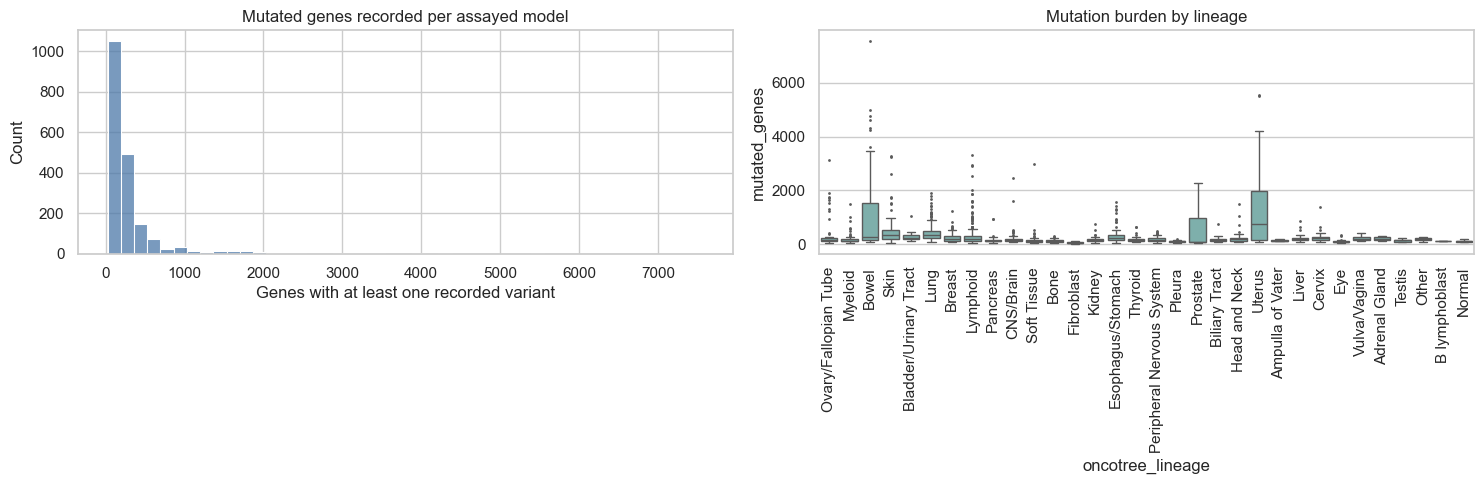

,model_id,oncotree_lineage,has_any_mutation_event,mutated_genes,recorded_variants,genes_with_likely_lof,genes_with_hotspot,high_burden_review_flag
957,ACH-000999,Bowel,1,7573,12303,1653,19,True
954,ACH-000996,Uterus,1,5554,8419,1159,34,True
948,ACH-000990,Uterus,1,5516,7623,1204,4,True
956,ACH-000998,Bowel,1,4992,6817,1624,7,True
955,ACH-000997,Bowel,1,4771,6294,722,9,True
988,ACH-001061,Bowel,1,4619,6106,649,9,True
949,ACH-000991,Bowel,1,4312,6120,964,37,True
995,ACH-001081,Bowel,1,4244,5944,777,55,True
952,ACH-000994,Uterus,1,4216,5374,1251,8,True
936,ACH-000978,Uterus,1,4023,5080,1388,3,True


In [3]:
burden = mutations.groupby('model_id').agg(
    mutated_genes=('gene_id', 'nunique'),
    recorded_variants=('n_variants', 'sum'),
    genes_with_likely_lof=('has_likely_lof', 'sum'),
    genes_with_hotspot=('has_hotspot', 'sum'),
).reset_index()

burden = assayed.merge(burden, on='model_id', how='left', validate='one_to_one')
burden[['mutated_genes', 'recorded_variants', 'genes_with_likely_lof', 'genes_with_hotspot']] = burden[['mutated_genes', 'recorded_variants', 'genes_with_likely_lof', 'genes_with_hotspot']].fillna(0)
display(burden[['mutated_genes', 'recorded_variants', 'genes_with_likely_lof', 'genes_with_hotspot']].describe().T)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(burden['mutated_genes'], bins=45, ax=axes[0], color='#4C78A8')
axes[0].set_title('Mutated genes recorded per assayed model')
axes[0].set_xlabel('Genes with at least one recorded variant')
sns.boxplot(data=burden, x='oncotree_lineage', y='mutated_genes', ax=axes[1], color='#76B7B2', fliersize=1)
axes[1].set_title('Mutation burden by lineage')
axes[1].tick_params(axis='x', rotation=90)
plt.tight_layout(); plt.show()

q1, q3 = burden['mutated_genes'].quantile([0.25, 0.75])
review_cutoff = q3 + 1.5 * (q3 - q1)
burden['high_burden_review_flag'] = burden['mutated_genes'].gt(review_cutoff)
display(burden.loc[burden['high_burden_review_flag']].sort_values('mutated_genes', ascending=False).head(30))

### What this means for the project

A model with hundreds of altered genes provides many chances to find an apparent relationship by coincidence. We do not automatically remove it. We mark it, compare results with and without high-burden models, and show whether a candidate gene-pair conclusion depends on them.

## 3. Mutation types and technical evidence

Different flags answer different biological questions. Loss-of-function evidence is especially relevant when asking whether losing gene A makes a cell dependent on gene B. Hotspots often identify repeated activating events, while tumour-suppressor and oncogene annotations add gene-role context.

,highest_vep_impact,model_gene_rows
0,HIGH,112691.0
1,MODERATE,533860.0
2,LOW,18.0
3,MODIFIER,372.0


,model_gene_rows,pct_of_model_gene_rows
has_likely_lof,113950,17.61
has_hotspot,3572,0.55
has_oncogene_high_impact,2704,0.42
has_tumor_suppressor_high_impact,6436,0.99


driver_like_event,False,True,All
damaging_event,,,
False,531052,1939,532991
True,104297,9653,113950
All,635349,11592,646941


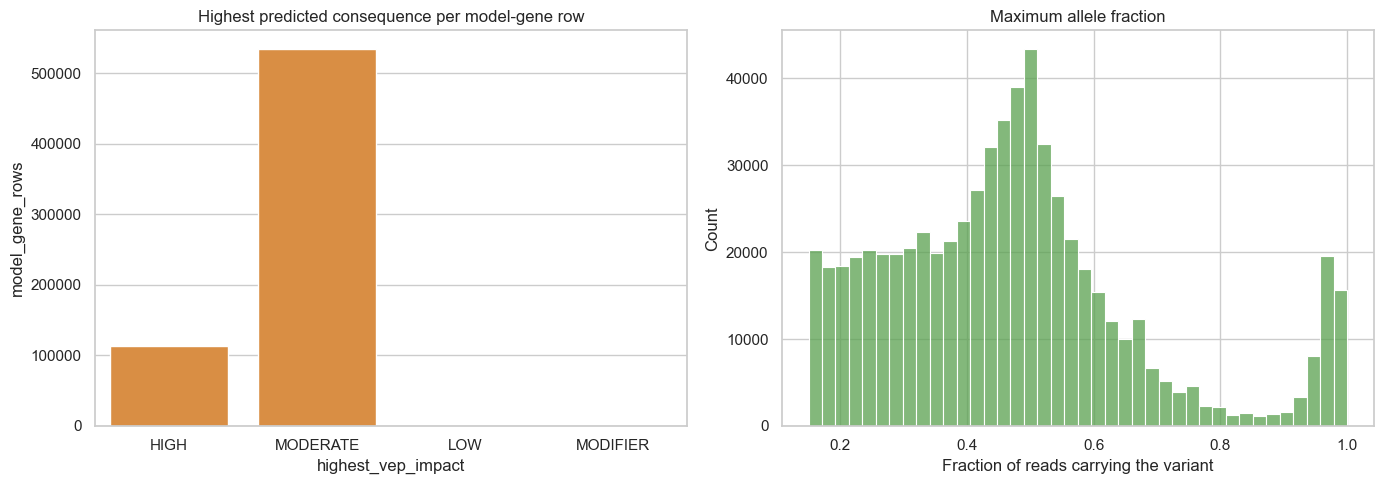

In [4]:
impact_order = ['HIGH', 'MODERATE', 'LOW', 'MODIFIER', 'Missing']
impact_counts = mutations['highest_vep_impact'].fillna('Missing').value_counts().reindex(impact_order).dropna().rename_axis('highest_vep_impact').reset_index(name='model_gene_rows')
display(impact_counts)

flag_summary = pd.DataFrame({
    'model_gene_rows': mutations[flag_columns].sum(),
    'pct_of_model_gene_rows': (100 * mutations[flag_columns].mean()).round(2),
})
display(flag_summary)

mutations['driver_like_event'] = mutations[['has_hotspot', 'has_oncogene_high_impact', 'has_tumor_suppressor_high_impact']].eq(1).any(axis=1)
mutations['damaging_event'] = mutations['has_likely_lof'].eq(1) | mutations['highest_vep_impact'].eq('HIGH')
overlap = pd.crosstab(mutations['damaging_event'], mutations['driver_like_event'], margins=True)
display(overlap)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=impact_counts, x='highest_vep_impact', y='model_gene_rows', ax=axes[0], color='#F28E2B')
axes[0].set_title('Highest predicted consequence per model-gene row')
sns.histplot(mutations['max_allele_fraction'].dropna(), bins=40, ax=axes[1], color='#59A14F')
axes[1].set_title('Maximum allele fraction')
axes[1].set_xlabel('Fraction of reads carrying the variant')
plt.tight_layout(); plt.show()

### What this means for the project

A hotspot and a likely loss-of-function mutation are not interchangeable. For example, an oncogene can become overactive through a hotspot mutation, while a tumour-suppressor gene is often important when it is damaged or lost. The later white-box feature table will preserve these reasons separately before creating any combined alteration definition.

## 4. Recurrent genes and lineage context

A recurrently mutated gene appears in many models. Recurrence can suggest biological importance, but it can also reflect gene length or one heavily represented cancer lineage. We calculate prevalence using assayed models as the denominator.

,gene_id,hugo_symbol,mutated_models,damaging_models,hotspot_models,mutated_pct_of_assayed_models
8370,ENSG00000145113,MUC4,1216,122,0,63.04
7852,ENSG00000141510,TP53,1174,1125,874,60.86
9547,ENSG00000155657,TTN,1037,271,5,53.76
16766,ENSG00000205592,MUC19,820,165,0,42.51
14065,ENSG00000181143,MUC16,801,121,0,41.52
12177,ENSG00000169894,MUC3A,788,26,0,40.85
16305,ENSG00000198786,MT-ND5,613,39,0,31.78
16281,ENSG00000198727,MT-CYB,538,10,0,27.89
14852,ENSG00000185567,AHNAK2,477,51,0,24.73
9431,ENSG00000154358,OBSCN,422,72,0,21.88


hugo_symbol,ARID1A,BRAF,BRCA1,BRCA2,CDKN2A,KRAS,PIK3CA,PTEN,RB1,TP53
oncotree_lineage,,,,,,,,,,
Adrenal Gland,0.0,0.0,0.0,50.0,0.0,0.0,0.0,0.0,0.0,50.0
Ampulla of Vater,0.0,25.0,0.0,0.0,75.0,50.0,25.0,0.0,0.0,50.0
Biliary Tract,17.4,8.7,0.0,4.3,4.3,30.4,4.3,6.5,6.5,71.7
Bladder/Urinary Tract,25.6,2.6,10.3,2.6,10.3,2.6,33.3,7.7,23.1,79.5
Bone,4.8,1.2,0.0,1.2,3.6,1.2,2.4,1.2,10.7,52.4
Bowel,24.2,31.9,9.9,24.2,7.7,52.7,30.8,13.2,2.2,79.1
Breast,14.7,6.7,8.0,10.7,5.3,4.0,33.3,16.0,6.7,76.0
CNS/Brain,6.2,6.2,4.4,3.5,3.5,1.8,5.3,41.6,15.9,67.3
Cervix,8.7,4.3,8.7,13.0,8.7,8.7,30.4,4.3,13.0,17.4


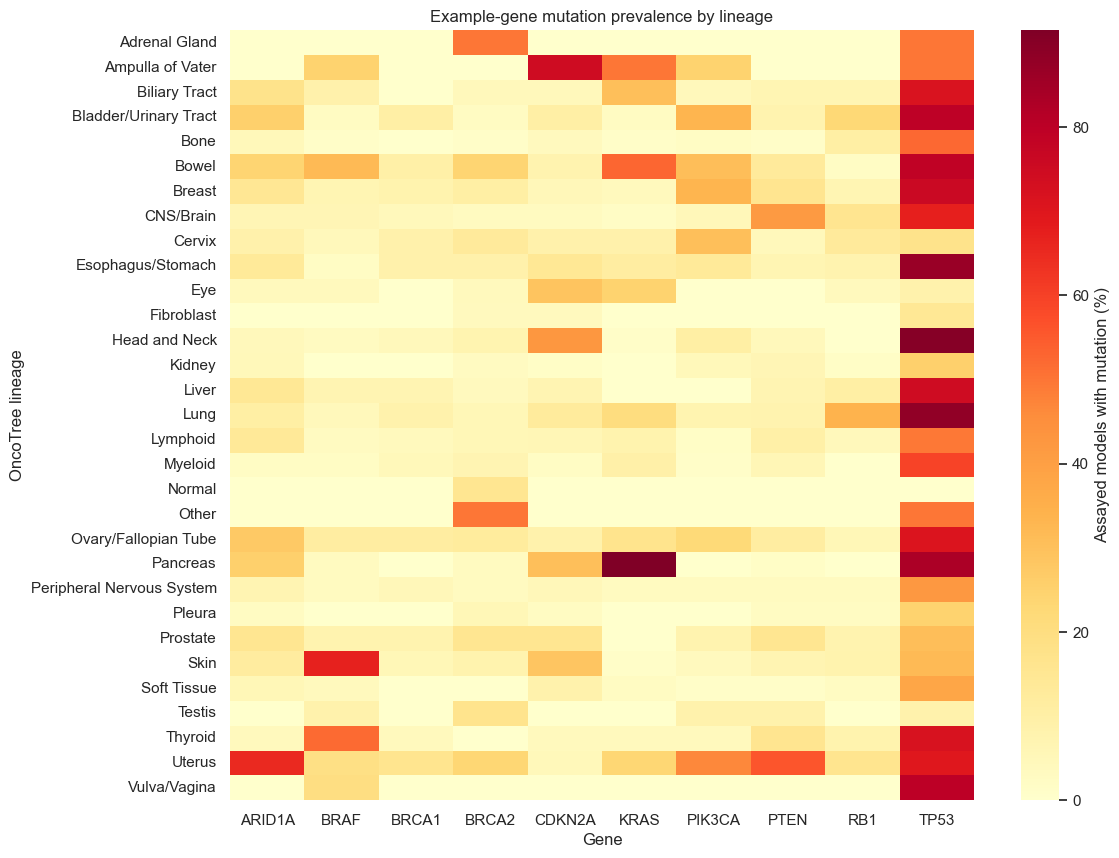

In [5]:
gene_recurrence = mutations.groupby(['gene_id', 'hugo_symbol']).agg(
    mutated_models=('model_id', 'nunique'),
    damaging_models=('damaging_event', 'sum'),
    hotspot_models=('has_hotspot', 'sum'),
).reset_index()
gene_recurrence['mutated_pct_of_assayed_models'] = (100 * gene_recurrence['mutated_models'] / len(assayed)).round(2)
display(gene_recurrence.nlargest(30, 'mutated_models'))

EXAMPLE_GENES = ['TP53', 'KRAS', 'BRAF', 'PIK3CA', 'PTEN', 'RB1', 'CDKN2A', 'BRCA1', 'BRCA2', 'ARID1A']
example_events = mutations.loc[mutations['hugo_symbol'].isin(EXAMPLE_GENES)].merge(master[['model_id', 'oncotree_lineage']], on='model_id', how='left', validate='many_to_one')
lineage_denominator = assayed.groupby('oncotree_lineage').size().rename('assayed_models')
example_lineage = example_events.groupby(['oncotree_lineage', 'hugo_symbol'])['model_id'].nunique().rename('mutated_models').reset_index().merge(lineage_denominator, on='oncotree_lineage', how='left')
example_lineage['mutated_pct'] = (100 * example_lineage['mutated_models'] / example_lineage['assayed_models']).round(1)
pivot = example_lineage.pivot(index='oncotree_lineage', columns='hugo_symbol', values='mutated_pct').fillna(0)
display(pivot)

plt.figure(figsize=(12, 10))
sns.heatmap(pivot, cmap='YlOrRd', cbar_kws={'label': 'Assayed models with mutation (%)'})
plt.title('Example-gene mutation prevalence by lineage')
plt.xlabel('Gene'); plt.ylabel('OncoTree lineage'); plt.show()

### What this means for the project

If `KRAS` mutations are common in one lineage, a pooled gene-B dependency difference may really be a lineage difference. We will compare altered and unaltered models within the same sufficiently large lineage, or explicitly adjust for lineage, before calling the result conditional dependency.

## 5. Alteration-definition sensitivity

There is no single perfect rule for "gene A is altered." We compare transparent definitions so the later result can show whether it depends on a broad or strict interpretation.

,gene,assayed_models_denominator,any_recorded_variant,likely_loss_of_function,high_VEP_or_likely_LoF,hotspot_or_gene_role_high_impact
0,ARID1A,1929,242,165,165,165
1,BRCA1,1929,102,33,33,29
2,BRCA2,1929,138,58,58,58
3,TP53,1929,1174,1125,1125,1105
4,KRAS,1929,250,0,0,232


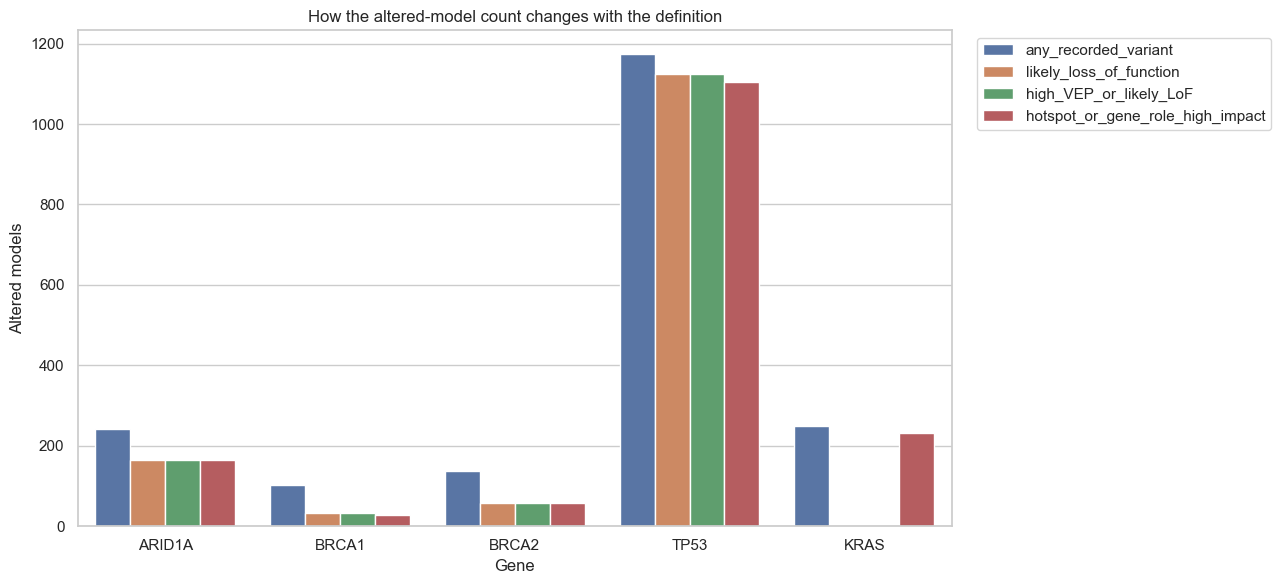

In [6]:
DEFINITION_GENES = ['ARID1A', 'BRCA1', 'BRCA2', 'TP53', 'KRAS']
definition_rows = []
for gene in DEFINITION_GENES:
    events = mutations.loc[mutations['hugo_symbol'].eq(gene)].copy()
    definition_rows.append({
        'gene': gene,
        'assayed_models_denominator': len(assayed),
        'any_recorded_variant': events['model_id'].nunique(),
        'likely_loss_of_function': events.loc[events['has_likely_lof'].eq(1), 'model_id'].nunique(),
        'high_VEP_or_likely_LoF': events.loc[events['damaging_event'], 'model_id'].nunique(),
        'hotspot_or_gene_role_high_impact': events.loc[events['driver_like_event'], 'model_id'].nunique(),
    })
definition_sensitivity = pd.DataFrame(definition_rows)
display(definition_sensitivity)

definition_long = definition_sensitivity.melt(id_vars=['gene', 'assayed_models_denominator'], var_name='alteration_definition', value_name='altered_models')
plt.figure(figsize=(13, 6))
sns.barplot(data=definition_long, x='gene', y='altered_models', hue='alteration_definition')
plt.title('How the altered-model count changes with the definition')
plt.xlabel('Gene'); plt.ylabel('Altered models'); plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()

### What this means for the project

For `ARID1A`, "any mutation" may include changes with unclear functional effect, while "likely loss of function" is stricter and may leave fewer models. The later conditional-dependency analysis will report both the definition and the resulting altered/unaltered sample sizes instead of hiding that choice inside an algorithm.

## Decisions carried into feature engineering

- Build gene-A alteration status only inside models with `has_mutation_assay=1`.
- Keep `any_variant`, `likely_lof`, `hotspot`, `oncogene_high_impact`, `tumour_suppressor_high_impact`, and `highest_vep_impact` as visible components.
- Start conditional-dependency sensitivity analysis with at least a broad and a strict alteration definition.
- Carry mutation burden and high-burden review flags as context; test conclusions with and without review-flagged models.
- Compare altered and unaltered groups within lineage or using an explicit lineage adjustment.
- Do not call a computationally predicted damaging event proven loss of gene function.